# Vital Signs EDA: 3-Variable Analysis (HR, SBP, DBP)

Focused analysis on the 3 cardiovascular vitals selected for LSTM modeling:
- **Heart Rate** (LOINC 8867-4)
- **Systolic Blood Pressure** (LOINC 8480-6)
- **Diastolic Blood Pressure** (LOINC 8462-4)

**Rationale for dropping other vitals:**
- **Temperature** — missing ~90% of timestamps, MCAR rejected (see 5v EDA)
- **Respiratory Rate** — observation-recorded, noisy signal
- **SpO2** — skewed distribution, confounded by unmeasured conditions

**No missingness section** — SBP/DBP co-occur from the same BP measurement; formal MCAR testing is not meaningful for 3 cardiovascular vitals.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

sys.path.insert(0, str(Path.cwd().parent))

from src.eda.queries import run_query
from src.eda.vitals import (
    VITALS_3,
    connect_vitals,
    plot_completeness_bar,
    plot_delta_histogram,
)

V3 = VITALS_3
conn = connect_vitals()
print("Connected.")

Connected.


## 2. Data Overview

In [2]:
schema = run_query(conn, "schema")
counts = run_query(conn, "counts")
sample = run_query(conn, "sample")

display(schema)
display(counts)
display(sample)

,column_name,column_type,null,key,default,extra
0,patient_id,VARCHAR,YES,None,None,None
1,encounter_id,VARCHAR,YES,None,None,None
2,effective_datetime,VARCHAR,YES,None,None,None
3,loinc_code,VARCHAR,YES,None,None,None
4,value,DOUBLE,YES,None,None,None
5,unit,VARCHAR,YES,None,None,None


,total_rows,unique_patients,unique_encounters,unique_vitals
0,10996821,205504,425087,6


,patient_id,encounter_id,effective_datetime,loinc_code,value,unit
0,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,2708-6,98.0,%
1,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,8310-5,98.7,F
2,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,8462-4,71.0,mm[Hg]
3,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,8480-6,141.0,mm[Hg]
4,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,8867-4,96.0,beats/minute
5,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,9279-1,18.0,breaths/minute
6,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:35:00-04:00,2708-6,98.0,%
7,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:35:00-04:00,8310-5,98.7,F
8,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:35:00-04:00,8462-4,71.0,mm[Hg]
9,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:35:00-04:00,8480-6,141.0,mm[Hg]


## 3. Timestamp Completeness (3 Vitals)

,num_vitals,num_timestamps,pct
0,2,83587,4.37
1,3,1827675,95.63


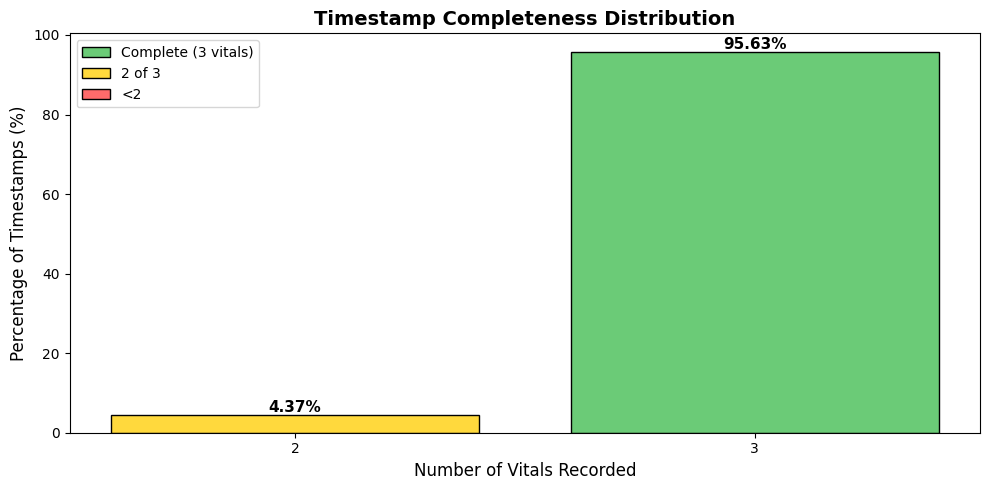

In [3]:
completeness = run_query(conn, "completeness", vitals=V3)
display(completeness)

fig, ax = plt.subplots(figsize=(10, 5))
plot_completeness_bar(completeness, ax, n_vitals=3)
plt.tight_layout()
plt.show()

## 4. Time Delta Analysis

,n_deltas,min,p10,p25,p50_median,p75,p90,p95,max
0,1407625,0.3,3.0,34.0,101.0,185.0,271.0,332.0,40201.0


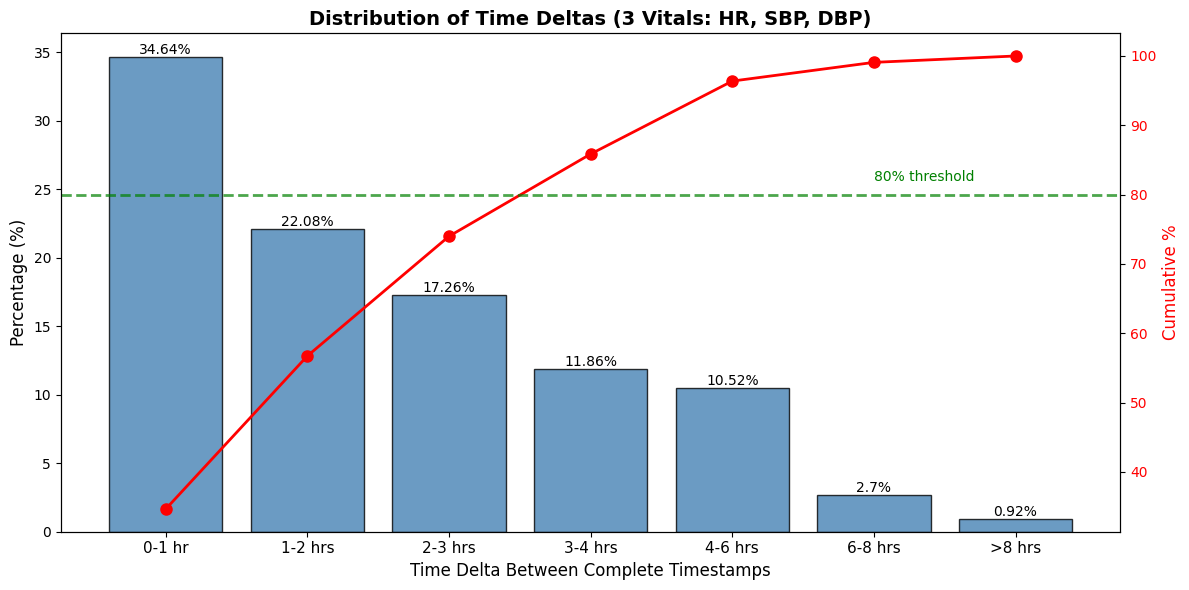

In [4]:
# Percentile summary
delta_stats = run_query(conn, "time_deltas", vitals=V3)
display(delta_stats)

# Bucketed histogram
buckets = run_query(conn, "time_delta_buckets", vitals=V3)

fig, ax = plt.subplots(figsize=(12, 6))
plot_delta_histogram(buckets, "Distribution of Time Deltas (3 Vitals: HR, SBP, DBP)", ax)
plt.tight_layout()
plt.show()

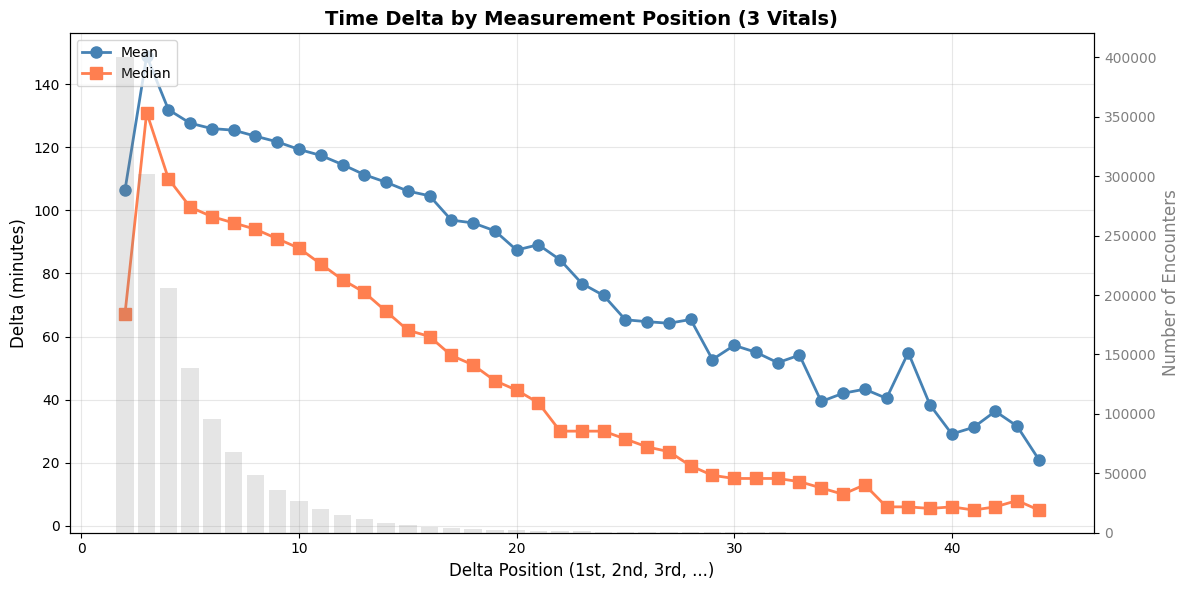

In [5]:
# Average delta by measurement position
delta_pos = run_query(conn, "delta_by_position", vitals=V3)
plot_data = delta_pos[delta_pos["n_encounters"] >= 50].copy()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(plot_data["delta_idx"], plot_data["avg_delta_min"], "o-", color="steelblue", linewidth=2, markersize=8, label="Mean")
ax1.plot(plot_data["delta_idx"], plot_data["median_delta_min"], "s-", color="coral", linewidth=2, markersize=8, label="Median")
ax1.set_xlabel("Delta Position (1st, 2nd, 3rd, ...)", fontsize=12)
ax1.set_ylabel("Delta (minutes)", fontsize=12)
ax1.set_title("Time Delta by Measurement Position (3 Vitals)", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(plot_data["delta_idx"], plot_data["n_encounters"], alpha=0.2, color="gray")
ax2.set_ylabel("Number of Encounters", fontsize=12, color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
plt.tight_layout()
plt.show()

## 5. Sequence Length & Coverage

,n_encounters,encounters_usable,pct_usable,p25,p50,p75,p95
0,425087,400253.0,94.2,2.0,3.0,5.0,10.0


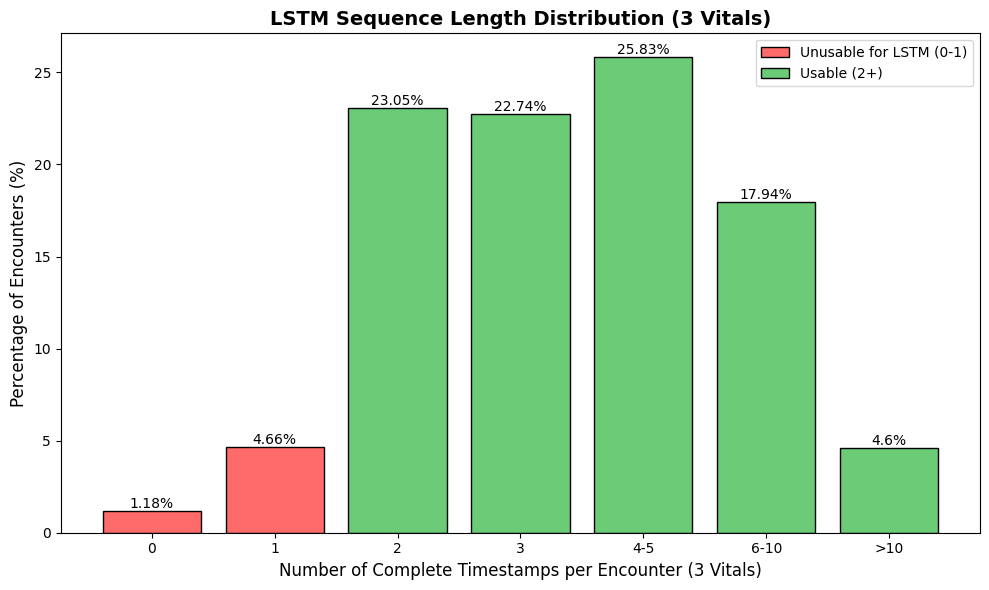

In [6]:
# Sequence length summary
seq_lengths = run_query(conn, "sequence_lengths", vitals=V3)
display(seq_lengths)

# Histogram of sequence lengths
seq_hist = run_query(conn, "sequence_length_hist", vitals=V3)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#ff6b6b" if x in ["0", "1"] else "#6bcb77" for x in seq_hist["seq_length"]]
bars = ax.bar(seq_hist["seq_length"], seq_hist["pct"], color=colors, edgecolor="black")
ax.set_xlabel("Number of Complete Timestamps per Encounter (3 Vitals)", fontsize=12)
ax.set_ylabel("Percentage of Encounters (%)", fontsize=12)
ax.set_title("LSTM Sequence Length Distribution (3 Vitals)", fontsize=14, fontweight="bold")
for bar, pct in zip(bars, seq_hist["pct"]):
    ax.annotate(f"{pct}%", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10)
ax.legend(handles=[
    Patch(facecolor="#ff6b6b", edgecolor="black", label="Unusable for LSTM (0-1)"),
    Patch(facecolor="#6bcb77", edgecolor="black", label="Usable (2+)"),
], loc="upper right")
plt.tight_layout()
plt.show()

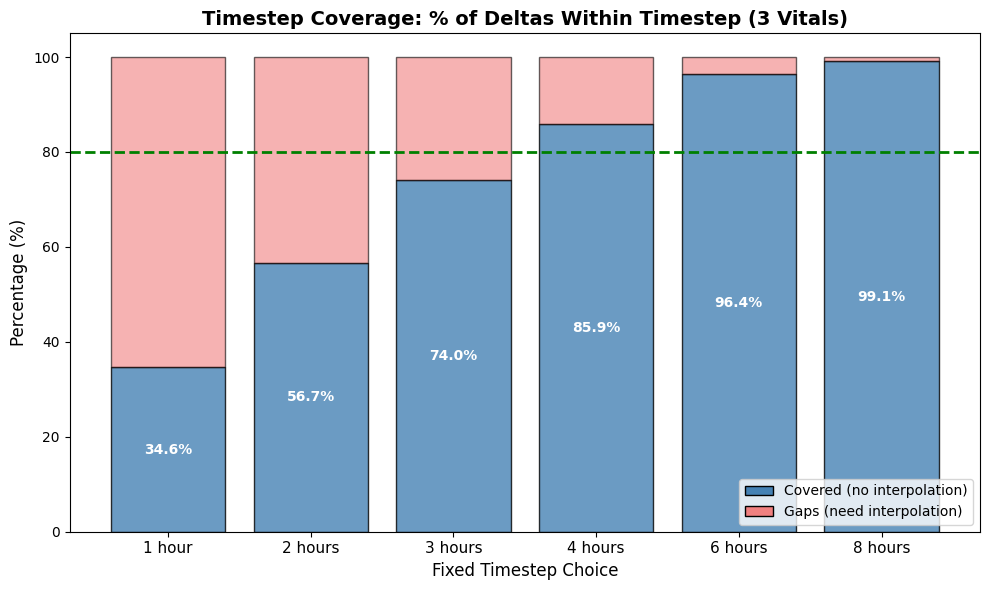

In [7]:
# Timestep coverage
coverage = run_query(conn, "timestep_coverage", vitals=V3)
coverage["gaps_to_fill"] = 100 - coverage["pct_covered"]

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(coverage))
ax.bar(x, coverage["pct_covered"], color="steelblue", edgecolor="black", alpha=0.8)
ax.bar(x, coverage["gaps_to_fill"], bottom=coverage["pct_covered"], color="lightcoral", edgecolor="black", alpha=0.6)
ax.set_xticks(list(x))
ax.set_xticklabels(coverage["timestep_label"], fontsize=11)
ax.set_xlabel("Fixed Timestep Choice", fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_title("Timestep Coverage: % of Deltas Within Timestep (3 Vitals)", fontsize=14, fontweight="bold")
ax.axhline(y=80, color="green", linestyle="--", linewidth=2, label="80% target")
for i, covered in enumerate(coverage["pct_covered"]):
    ax.annotate(f"{covered}%", xy=(i, covered / 2), ha="center", va="center", fontsize=10, fontweight="bold", color="white")
ax.legend(handles=[
    Patch(facecolor="steelblue", edgecolor="black", label="Covered (no interpolation)"),
    Patch(facecolor="lightcoral", edgecolor="black", label="Gaps (need interpolation)"),
], loc="lower right")
plt.tight_layout()
plt.show()

## 6. Sequence Length & Delta.

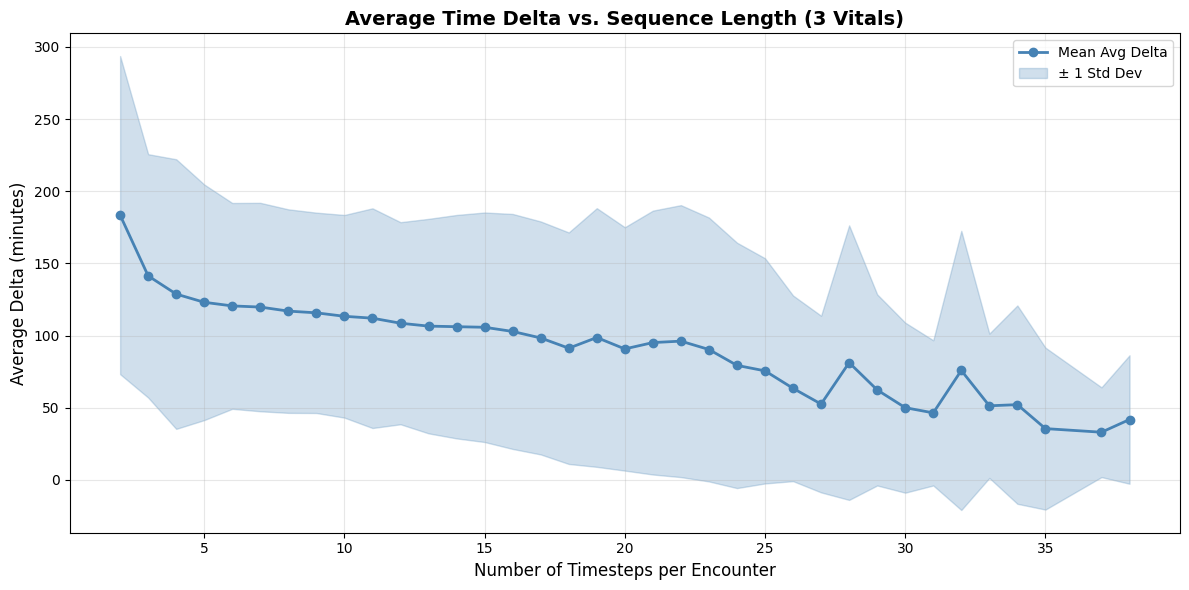

In [8]:
# Relationship between sequence length and average time delta
seq_delta = run_query(conn, "seq_length_vs_delta", vitals=V3)
plot_data = seq_delta[seq_delta["n_encounters"] >= 10].copy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot_data["n_timesteps"], plot_data["mean_avg_delta"],
        "o-", color="steelblue", linewidth=2, markersize=6, label="Mean Avg Delta")
ax.fill_between(
    plot_data["n_timesteps"],
    plot_data["mean_avg_delta"] - plot_data["std_avg_delta"],
    plot_data["mean_avg_delta"] + plot_data["std_avg_delta"],
    alpha=0.25, color="steelblue", label="\u00b1 1 Std Dev",
)
ax.set_xlabel("Number of Timesteps per Encounter", fontsize=12)
ax.set_ylabel("Average Delta (minutes)", fontsize=12)
ax.set_title("Average Time Delta vs. Sequence Length (3 Vitals)",
             fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Sequence length histogram + reverse cumulative
seq_dist = run_query(conn, "seq_length_distribution", vitals=V3)

# Reverse cumulative: encounters with >= n timesteps
seq_dist["reverse_cumulative"] = seq_dist["n_encounters"][::-1].cumsum()[::-1]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Histogram bars
ax1.bar(seq_dist["n_timesteps"], seq_dist["n_encounters"],
        color="steelblue", edgecolor="black", alpha=0.8, label="Frequency")
ax1.set_xlabel("Number of Timesteps per Encounter", fontsize=12)
ax1.set_ylabel("Number of Encounters", fontsize=12)
ax1.set_title("Sequence Length Distribution (3 Vitals)",
              fontsize=14, fontweight="bold")

# Reverse cumulative on twin axis
ax2 = ax1.twinx()
ax2.plot(seq_dist["n_timesteps"], seq_dist["reverse_cumulative"],
         color="red", marker="o", linewidth=2, markersize=5, label="≥ N timesteps")
ax2.set_ylabel("Encounters with ≥ N Timesteps", fontsize=12, color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Summary

In [9]:
n_vitals = len(V3)
pct_usable = seq_lengths["pct_usable"].iloc[0]
median_delta = delta_stats["p50_median"].iloc[0]

print(f"""
KEY FINDINGS ({n_vitals}-Vital Analysis: HR, SBP, DBP)
{'=' * 50}

1. COMPLETENESS
   - {n_vitals} cardiovascular vitals co-occur frequently
   - SBP & DBP come from the same BP measurement

2. TIME DELTAS
   - Median delta: ~{median_delta:.0f} minutes between complete timestamps
   - More usable timestamps than the 5v analysis

3. SEQUENCE LENGTHS
   - ~{pct_usable:.0f}% of encounters have 2+ complete timestamps (usable for LSTM)

4. TIMESTEP RECOMMENDATION
   - Check coverage chart above for optimal timestep choice
""")

conn.close()
print("Connection closed.")


KEY FINDINGS (3-Vital Analysis: HR, SBP, DBP)

1. COMPLETENESS
   - 3 cardiovascular vitals co-occur frequently
   - SBP & DBP come from the same BP measurement

2. TIME DELTAS
   - Median delta: ~101 minutes between complete timestamps
   - More usable timestamps than the 5v analysis

3. SEQUENCE LENGTHS
   - ~94% of encounters have 2+ complete timestamps (usable for LSTM)

4. TIMESTEP RECOMMENDATION
   - Check coverage chart above for optimal timestep choice

Connection closed.
